---
title: Simulate time evolution of the transverse-field Ising model
description: Use Qiskit.jl to simulate time evolution of the transverse-field Ising model on IBM Quantum hardware
---

{/* cspell:ignore Néel spdiagm Runge Kutta tspan saveat siteinds Neel maxdim tensornetworkstate println countmap clims xlabel ylabel colorbar */}

# Simulate time evolution of the transverse-field Ising model

## Learning outcomes
1. Learn how to transpile and run quantum circuits on the hardware using Julia
2. Learn how to post-process measurement outcomes to compute expectation values
3. Learn how to benchmark hardware results against classical simulation to quantify the combined effects of Trotter approximation error and hardware noise

## Background

Julia is a dynamic programming language designed primarily for numerical and scientific computing. Its high-performance numerical computing capabilities make it a natural fit for quantum simulation workflows. In this tutorial, we will show how Julia is used for both classical pre- and post-processing (e.g., building Hamiltonians, running ODE solvers, computing expectation values) and for orchestrating quantum hardware jobs, eliminating the need to switch between languages or environments.

To interface with IBM Quantum hardware from Julia, this tutorial uses two packages from the Qiskit ecosystem: `Qiskit.jl` wraps the Qiskit C library and provides circuit construction and transpilation functionality in Julia; `QiskitIBMRuntime.jl` connects to IBM Quantum hardware through the Qiskit IBM Runtime service, enabling job submission and result retrieval directly from Julia.

In this tutorial, we consider the trotterized evolution of the transverse-field Ising model on a 1D chain with nearest-neighbor interactions:

$$
    H = \sum_{\langle i,j\rangle}J_{ij}Z_iZ_j + \sum_i h_i X_i
$$

To implement the time evolution $e^{-iH\tau}$, we divide the time interval $\tau$ into $r$ steps and define $\Delta\tau=\tau/r$. The second-order Trotter-Suzuki decomposition gives:
$$
    e^{-iH\Delta\tau}\approx \prod_i e^{-ih_i X_i\Delta\tau/2 } \prod_{\langle i,j\rangle} e^{-iJ_{ij}Z_iZ_j\Delta\tau} \prod_i e^{-ih_iX_i\Delta\tau/2}
$$

For circuit construction, each Trotter step is implemented as a sequence of single-qubit $R_x$ rotations and two-qubit $R_{ZZ}$ gates. The circuit begins by preparing the Néel state $|0101\cdots\rangle$ using X gates on alternating qubits. Each subsequent Trotter step applies: (1) $R_x(h_i\Delta\tau/2)$ on every qubit, (2) $R_{ZZ}(2J_{ij}\Delta\tau)$ on each neighboring pair along the chain, and (3) $R_x(h_i\Delta\tau/2)$ again on every qubit. The total circuit depth grows linearly with the number of Trotter steps $r$.

## Requirements

Note that this tutorial requires macOS or Linux — Qiskit.jl is not currently supported on Windows (tracked in [this open issue](https://github.com/Qiskit/Qiskit.jl/issues/15)).

To get started, install Julia, following the instructions on the [Julia download page](https://julialang.org/downloads/).

Then, run the following command in a terminal to install the Julia package `IJulia.jl` into the global environment; this will allow us to use the Julia programming language inside the Jupyter notebook.

```
julia -e 'using Pkg; Pkg.add("IJulia")'
```

This tutorial also comes with two additional files: `Project.toml` and `Manifest.toml`. The project file describes the project at a high level — for example, the `[deps]` section lists all dependencies. The manifest file records the exact state of those dependencies, allowing you to reproduce the same project environment. See the [Julia documentation](https://pkgdocs.julialang.org/v1/toml-files/) for more on these files.

We will use Julia's built-in package manager to set up the project environment. We run the code cell below to activate the environment defined by the `Project.toml` and `Manifest.toml` files in the current directory.

In [1]:
# Activate the project environment and list installed packages
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/documentation/docs/tutorials/time-evolution`


The cell below installs all dependencies listed in `Project.toml`, with versions pinned as specified in Manifest.toml. The following packages will be installed:

For quantum circuit construction and execution:
* `Qiskit.jl`
* `QiskitIBMRuntime.jl`

For classical simulation:
* `OrdinaryDiffEq.jl`
* `TensorNetworkQuantumSimulator.jl`

For post-processing results and visualization:
* `StatsBase.jl`
* `JSON.jl`
* `Plots.jl`

In [2]:
# Download and install all packages specified in Project.toml
Pkg.instantiate()

Up to this point, we have set up the Julia project environment to run the notebook. In order to run the workflow on IBM's quantum processing unit, an IBM Quantum account and API token are also required to instantiate Service from Qiskit IBM Runtime. Follow the "Install and authenticate" steps in the [IBM Quantum getting started guide](https://quantum.cloud.ibm.com/docs/en/guides/hello-world) to generate your API token and find your instance CRN — the account setup steps apply regardless of programming language.

## Setup

In [3]:
using Qiskit
using QiskitIBMRuntime
using StatsBase
using OrdinaryDiffEq
using SparseArrays
using LinearAlgebra
using TensorNetworkQuantumSimulator
using Dates
using JSON
using Plots
using Plots.PlotMeasures

We will also define the following utility function which returns the value of the bit in a bitstring `v` at position `i`. For example, with `v = 6` (binary `110`),
- `bit_at(6, 1)` returns `0`,
- `bit_at(6, 2)` returns `1`,
- `bit_at(6, 3)` returns `1`.

This follows Qiskit's little endian convention, i.e., the position `i` is indexed from the least-significant (the "rightmost") bit.

In [4]:
"""
    bit_at(v::Integer, i::Integer) = (v >> (i-1)) & 1

Return the value of the bit at position `i` in `v`.
"""
bit_at(v::Integer, i::Integer) = (v >> (i-1)) & 1

bit_at

## Small-scale simulator example

We consider a 1D chain of $N$ qubits, described by the transverse-field Ising model above. For the system of interest, we specify below the system size `N`, the Trotter step size `δt`, and the total number of Trotter steps `r_max`. The total evolution time is `δt * r_max`. Note that Julia supports Unicode identifiers such as `δt`; in the notebook or Julia REPL, type `\delta` followed by Tab to enter `δ`. For a full reference, see the [Julia Unicode input documentation](https://docs.julialang.org/en/v1/manual/unicode-input/).

### Exact solution
To establish a baseline for comparing results from the quantum hardware, we first demonstrate the classical simulation workflow for a small-scale problem. We build the Ising Hamiltonian as a sparse matrix, then obtain the exact time evolution by numerically integrating the Schrödinger equation using `ODEProblem` from `OrdinaryDiffEq.jl`. This approach scales exponentially in the number of qubits $N$. It requires storing the full $2^N$-dimensional state vector. For $N=20$ the Hilbert space already has over one million dimensions, making it impractical for larger systems.

In [5]:
N = 20
δt = 0.05 # Trotter step size
r_max = 10 # total number of Trotter steps

h = fill(1.0, N)
J = fill(1.0, N-1)

function build_ising_hamiltonian(h::Vector, J::Vector, n::Int)
    dim = 2^n

    # diagonal ZZ terms
    diag_terms = zeros(Float64, dim)
    for i in 1:n-1
        for b in 0:dim-1
            bi = bit_at(b, i) # bit at position i
            bi_next = bit_at(b, i+1) # bit at position i + 1
            diag_terms[b+1] += J[i] * (1-2bi) * (1-2bi_next)
        end
    end
    H = spdiagm(0 => complex(diag_terms))

    # off-diagonal local X terms
    for i in 1:n
        mask = 1 << (i-1)
        cols = [xor(b, mask) + 1 for b in 0:dim-1]
        H += h[i] * sparse(1:dim, cols, ones(ComplexF64, dim), dim, dim)
    end
    return H
end

H_ising = build_ising_hamiltonian(h, J, N)

1048576×1048576 SparseMatrixCSC{ComplexF64, Int64} with 22020096 stored entries:
⎡⣿⣿⣾⢦⡀⠳⣄⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⡀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠙⢦⡈⠳⣼⣿⣿⡆⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠙⢦⡀⠀⠀⠁⠀⠈⠈⠉⣿⣿⣾⢦⡀⠳⣄⠀⠀⠈⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠺⣟⢻⣶⣿⡂⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⢤⡈⠻⠻⠿⣧⣤⣠⡈⠳⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠀⣻⣿⣿⣙⣦⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡈⠳⣼⣿⣿⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⎥
⎢⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣿⡟⢦⡈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⠀⠀⠀⠈⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⡀⠀⠀⠙⢦⠈⠳⡿⣿⣿⣀⡀⡀⠀⢀⠀⠀⠈⠳⣄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠸⣿⣿⡟⢦⡈⠳⣄⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠈⠻⣍⣿⣿⣯⠀⠈⠳⣄⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠐⢦⡈⠋⠛⢻⣶⣦⣦⡈⠓⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢦⡀⠨⣿⠿⣧⣽⡦⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠀⠀⠀⠀⠀⠙⢦⠀⠀⠀⠙⢦⠈⠳⡿⣿⣿⎦

We define the right-hand side of the Schrödinger equation in the in-place form `schrodinger!(dψ, ψ, H, t)`, which computes $d\psi/dt = -iH\psi$ using a sparse matrix-vector multiplication. We then set up an `ODEProblem` with the Néel state as the initial condition and solve it over the time span $[0, r \cdot \delta t]$, saving the state at each time step $\delta t$. The solver used is `Tsit5()`, a standard explicit 4th/5th-order Runge-Kutta method suitable for non-stiff problems.

In [6]:
# initial state |0101...01⟩
ψ0 = zeros(ComplexF64, 2^N)
neel_index = sum(1 << (i-1) for i in 1:2:N)
ψ0[neel_index + 1] = 1.0

function schrodinger!(dψ, ψ, H, t)
    mul!(dψ, H, ψ)
    dψ .*= -im
end

tspan = (0.0, r_max * δt)
prob = ODEProblem(schrodinger!, ψ0, tspan, H_ising)
sol = solve(prob, Tsit5(), saveat=δt)

retcode: Success
Interpolation: 1st order linear
t: 11-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
u: 11-element Vector{Vector{ComplexF64}}:
 [0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im  …  0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im]
 [-8.447198152606215e-14 + 8.551269476709602e-30im, 8.452613704293039e-14 - 1.798092880310424e-12im, -1.083059452476694e-16 + 3.807165445547495e-15im, -8.452616757829304e-14 - 1.2684837509562956e-15im, 1.6905229445367383e-13 - 1.7942825729563814e-12im, 3.686879554841385e-11 + 5.3942753560200465e-12im, -8.441779547549441e-14 - 5.078648506287416e-15im, 8.452616758772015e-14 - 1.7980927376219225e-12im, -1.0836194633904448e-16 + 3.8093089835689296e-15im, -8.439610286431264e-14 - 6.349847282668091e-15im  …  -8.420097996175948e-14 - 8.886670419764126e-1

From the solution which describes the state vector $\psi(t)$, we can obtain the magnetization per site, expressed as the single-qubit $\langle Z\rangle$ expectation values as a function of time. We will compare this with the results obtained from the trotterized circuits.

In [7]:
function z_expval_from_state(ψ, qubit::Int, n::Int)
    s = 0.0
    for b in 0:2^n-1
        bit = bit_at(b, qubit)
        s += (1 - 2bit) * abs2(ψ[b+1])
    end
    return s
end

classical_magnetizations = [z_expval_from_state(sol.u[r+1], q, N)
                             for r in 0:r_max, q in 1:N]

11×20 Matrix{Float64}:
 -1.0       1.0       -1.0       1.0       …  1.0       -1.0       1.0
 -0.995009  0.995022  -0.995022  0.995022     0.995022  -0.995022  0.995009
 -0.980214  0.98041   -0.98041   0.98041      0.98041   -0.98041   0.980214
 -0.955737  0.956712  -0.956712  0.956712     0.956712  -0.956712  0.955737
 -0.922329  0.92532   -0.925321  0.925321     0.925321  -0.92532   0.922329
 -0.880651  0.887676  -0.887679  0.887679  …  0.887679  -0.887676  0.880651
 -0.831446  0.845337  -0.84535   0.84535      0.84535   -0.845337  0.831446
 -0.775847  0.800169  -0.800211  0.800211     0.800211  -0.800169  0.775847
 -0.714946  0.753787  -0.753898  0.753898     0.753898  -0.753787  0.714946
 -0.649935  0.707714  -0.707977  0.707978     0.707977  -0.707714  0.649935
 -0.579691  0.660741  -0.661309  0.661309  …  0.661309  -0.660741  0.579691

### Small-scale simulation of the Trotterized circuits

In the following, we show the classical simulation of the noiseless circuits using tensor network methods supported by `TensorNetworkQuantumSimulator.jl`. This allows us to validate our circuit construction and provides a baseline to compare with results from the quantum hardware.

We first define the lattice as a 1D chain graph using `named_grid((N,))`, where each vertex is a tuple `(i,)`. We then specify the circuit gates as a list of tuples `(gate_name, qubit_indices, gate_parameter)`, which serves as the input format for the tensor network simulator.

In [8]:
# 1D chain graph — vertices are named (1,), (2,), ..., (N,)
g = named_grid((N,))
s = siteinds("S=1/2", g)

function make_trotter_circuit_tn(h::Vector, J::Vector, n::Int, δt::Float64, n_trotter_steps::Int)
    circuit = []

    # Neel state initialization
    append!(circuit, [("X", [(i,)]) for i in 1:2:n])

    for _ in 1:n_trotter_steps
        # first half X rotation
        append!(circuit, [("Rx", [(i,)], h[i]* δt / 2) for i in 1:n])
        # ZZ interactions
        append!(circuit, [("Rzz", [(i,), (i+1,)], 2 * J[i] * δt) for i in 1:n-1])
        # second half X rotation
        append!(circuit, [("Rx", [(i,)], h[i] * δt / 2) for i in 1:n])
    end

    return circuit
end

make_trotter_circuit_tn (generic function with 1 method)

We use the belief propagation algorithm for tensor network contraction. This method is efficient for circuits with limited entanglement, but its accuracy degrades as entanglement grows with circuit depth. The `maxdim` and `cutoff` parameters control the trade-off between accuracy and computational cost. Similarly, we compute the magnetization at each site to compare later.

In [9]:
apply_kwargs = (; maxdim=32, cutoff=1e-10, normalize_tensors=true)
tn_magnetizations = zeros(r_max+1, N)
fidelities = []
for r in 0:r_max
    circuit = make_trotter_circuit_tn(h, J, N, δt, r)
    # initial state
    ψ = tensornetworkstate(ComplexF32, v -> "↑", g, "S=1/2")
    ψ_bpc = BeliefPropagationCache(ψ)
    ψ_bpc, errs = apply_gates(circuit, ψ_bpc; apply_kwargs)
    fidelity = prod(1.0 .- errs)
    println("fidelity at trotter step $(r) was $(fidelity)")
    push!(fidelities, fidelity)

    for q in 1:N
        tn_magnetizations[r+1, q] = real(expect(ψ_bpc, [("Z", [(q,)])])[1])
    end
end

fidelity at trotter step 0 was 1.0
fidelity at trotter step 1 was 1.0
fidelity at trotter step 2 was 1.0
fidelity at trotter step 3 was 1.0
fidelity at trotter step 4 was 0.9999999999999906
fidelity at trotter step 5 was 0.9999999999997938
fidelity at trotter step 6 was 0.9999999999975266
fidelity at trotter step 7 was 0.9999999999804221
fidelity at trotter step 8 was 0.9999999998846302
fidelity at trotter step 9 was 0.9999999994549151
fidelity at trotter step 10 was 0.9999999980378083


### Step 1: Map classical inputs to a quantum problem

Now we construct the trotterized time-evolution circuit using `Qiskit.jl`. The circuit mirrors the tensor network version: it initializes the Néel state, applies $r$ Trotter steps of $R_x$ and $R_{ZZ}$ gates, and finally measures all qubits in the Z basis.

In [10]:
function make_trotter_circuit(h::Vector, J::Vector, n::Int, δt::Float64, n_trotter_steps::Int)
    qc = QuantumCircuit(n, n)

    # Neel state initialization
    for i in 1:2:n
        qc.x(i)
    end

    # trotter evolution
    for _ in 1:n_trotter_steps
        for i in 1:n
            qc.rx(h[i] * δt / 2, i)
        end

        for i in 1:n-1
            qc.rzz(2* J[i] * δt, i, i+1)
        end

        for i in 1:n
            qc.rx(h[i] * δt / 2, i)
        end
    end

    # measure in Z basis
    for i in 1:n
        qc.measure(i, i)
    end
    return qc
end


qc = make_trotter_circuit(h, J, N, δt, 1)

QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000116669e00, 1)

We build a list of circuits for Trotter steps 0 through 10, corresponding to evolution times $\tau = 0, \delta t, 2\delta t, \ldots, 10\delta t$.

In [11]:
# prepare a list of circuits with different trotter steps
qc_list = [make_trotter_circuit(h, J, N, δt, r) for r in 0:r_max]

11-element Vector{QuantumCircuit}:
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000127759000, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000048b499a00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000012778ce00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000048b4cb800, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000048b181a00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000048b29d800, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x00000003525f4800, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x00000003525d5600, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352228c00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x00000003523ebe00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x00000003527ff000, 1)

### Step 2: Optimize problem for quantum hardware execution

To run on quantum hardware, the circuits must first be transpiled. This includes: selecting a set of physical qubits to map the circuit onto, recompiling the gates into the native instruction set of the backend, and optimizing the resulting circuit depth. We use `least_busy()` to automatically select the least-busy available backend, `target_from_backend()` to retrieve its native gate set and qubit connectivity, and `transpile()` to perform the compilation.

In [12]:
service = Service()
search_results = backend_search(service)
backend = least_busy(search_results)
@show backend.name

backend.name = "ibm_fez"


"ibm_fez"

In [13]:
target = target_from_backend(backend, service)

Qiskit.Target(Ptr{Qiskit.C.LibQiskit.QkTarget} @0x0000000498252d70)

In [14]:
tqc_list = [transpile(qc, target)[1] for qc in qc_list]

11-element Vector{QuantumCircuit}:
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352bb7000, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000115d34c00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352b45c00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352edf400, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000116117000, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000012775ec00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x00000001282f4a00, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352dc4200, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x000000048b779200, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000352f40600, 1)
 QuantumCircuit(Ptr{Qiskit.C.LibQiskit.QkCircuit} @0x0000000116050a00, 1)

After transpilation, we inspect two properties of the compiled circuits. `get_circuit_layout()` returns the set of physical qubit indices selected for the circuit. `two_qubit_depth()` computes the two-qubit gate depth — the length of the longest chain of the two-qubit operations in the circuit — which is a useful indicator of noise accumulation on the hardware.

In [15]:
function get_circuit_layout(tqc::QuantumCircuit)
    return Set(q for inst in tqc.data for q in inst.qubits)
end

get_circuit_layout(tqc_list[2])

Set{Int64} with 20 elements:
  56
  55
  52
  60
  28
  75
  53
  47
  49
  74
  80
  51
  46
  76
  48
  50
  54
  27
  38
  26

In [16]:
function two_qubit_depth(qc::QuantumCircuit)
    qubit_depth = Dict{Int,Int}()
    for inst in qc.data
        length(inst.qubits) == 2 || continue   # skip non-two-qubit gates
        d = maximum(get(qubit_depth, q, 0) for q in inst.qubits)
        for q in inst.qubits
            qubit_depth[q] = d + 1
        end
    end
    return isempty(qubit_depth) ? 0 : maximum(values(qubit_depth))
end

for (i, tqc) in enumerate(tqc_list)
    println("r=$(i-1): 2q depth=$(two_qubit_depth(tqc))")
end

r=0: 2q depth=0
r=1: 2q depth=38
r=2: 2q depth=42
r=3: 2q depth=46
r=4: 2q depth=50
r=5: 2q depth=54
r=6: 2q depth=58
r=7: 2q depth=62
r=8: 2q depth=66
r=9: 2q depth=70
r=10: 2q depth=74


### Step 3: Execute using Qiskit primitives

Now, we can submit the transpiled circuits to the backend as `Sampler` jobs with `shots` specified.

In [17]:
shots = 1024
job_list = [run_sampler_job(service, backend, tqc, shots) for tqc in tqc_list]

11-element Vector{QiskitIBMRuntime.Job}:
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048fa82730)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048deb9900)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048f38b310)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377fec9c0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048de54e80)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377d2acb0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004983ac830)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004983d8980)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377f611a0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377f50da0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @

In [18]:
job_list

11-element Vector{QiskitIBMRuntime.Job}:
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048fa82730)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048deb9900)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048f38b310)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377fec9c0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x000000048de54e80)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377d2acb0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004983ac830)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x00000004983d8980)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377f611a0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @0x0000000377f50da0)
 QiskitIBMRuntime.Job(Ptr{QiskitIBMRuntime.LibQiskitIBMRuntime.Job} @

In [24]:
for (i, job) in enumerate(job_list)
    status = get_job_status(job, service)
    println("Job $i: ", status)
end

Job 1: Completed
Job 2: Completed
Job 3: Completed
Job 4: Completed
Job 5: Completed
Job 6: Completed
Job 7: Completed
Job 8: Completed
Job 9: Completed
Job 10: Completed
Job 11: Completed


As the jobs are completed, we can retrieve their results. Note that `get_job_results` function will block until the job is completed.

In [25]:
all_samples = [get_job_results(job, service) for job in job_list]

11-element Vector{QiskitIBMRuntime.Samples}:
 ["0x55555", "0x55555", "0x15555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555"  …  "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555", "0x55555"]
 ["0x51574", "0x55155", "0x55555", "0x55555", "0x55455", "0x55455", "0x55454", "0x55555", "0x55555", "0x55d54"  …  "0x55555", "0x55545", "0x55155", "0x55454", "0x55555", "0x55555", "0x95554", "0x55555", "0x55551", "0x45555"]
 ["0x55555", "0x51455", "0xd5555", "0x15545", "0x55551", "0x55555", "0x55455", "0x55555", "0x55545", "0x55511"  …  "0x54555", "0x55555", "0x51555", "0x55455", "0x515d5", "0x55455", "0x551d1", "0x5d515", "0x55555", "0x55455"]
 ["0x44555", "0x54155", "0x50554", "0x55555", "0x54354", "0x54555", "0x54555", "0x54055", "0x54054", "0x55450"  …  "0x55555", "0x55155", "0x54155", "0x55515", "0x55455", "0x555d5", "0x57455", "0x55556", "0x554d1", "0x55545"]
 ["0x54450", "0xd4555", "0x56154", "0x5a556", "0x54455"

### Step 4: Post-process and return result in desired classical format

The hardware returns measurement outcomes in hexadecimal format. We define `hex_to_bitstrings()` to decode each hex value into a bitstring of length $N$. The `save_counts()` function aggregates the raw samples into a bitstring-to-count dictionary using `countmap()`, then writes the result to a JSON file on disk.

In [26]:
# from hex to bitstrings
function hex_to_bitstrings(s::String, n::Int)
    val = parse(Int, replace(s, "0x" => ""), base=16)
    join([bit_at(val, i) for i in 1:n])
end

hex_to_bitstrings("0x8", 4)

"0001"

In [27]:
# Save counts
function save_counts(all_samples::Vector{QiskitIBMRuntime.Samples}, N::Int; dir::String="results")
    mkpath(dir)
    all_counts = [Dict(hex_to_bitstrings(k, N) => v for (k, v) in countmap(s)) for s in all_samples]

    date_str = Dates.format(Dates.now(), "yyyy-mm-dd_HHMMSS")
    open(joinpath(dir, "counts_N=$(N)_$(date_str).json"), "w") do f
        JSON.print(f, all_counts, 2)
    end
    println("Saved to $(joinpath(dir, "counts_N=$(N)_$(date_str).json"))")
end

save_counts(all_samples, N)

Saved to results/counts_N=20_2026-06-23_183705.json


From the bitstring samples obtained from the quantum hardware, we compute the magnetization per site (i.e., the single-qubit $\langle Z\rangle$ expectation values) by averaging $(-1)^{b_i}$ over all shots, where $b_i$ is the measured bit for qubit $i$. We then plot the magnetization as a heatmap over qubits and Trotter steps, comparing the three methods side by side: exact classical simulation, noiseless tensor network simulation, and hardware execution.

In [28]:
# Compute expectation values
# 0 -> 1, 1 -> -1
function z_expval_from_samples(samples, qubit::Int, n::Int)
    mean((-1) ^ parse(Int, hex_to_bitstrings(s, n)[qubit]) for s in samples)
end

magnetizations = [z_expval_from_samples(all_samples[i], q, N) for i in 1:length(all_samples), q in 1:N]

11×20 Matrix{Float64}:
 -0.994141  0.998047  -0.984375  0.994141  …  0.994141  -0.982422  0.998047
 -0.740234  0.892578  -0.876953  0.953125     0.957031  -0.916016  0.960938
 -0.908203  0.947266  -0.771484  0.912109     0.917969  -0.832031  0.935547
 -0.783203  0.9375    -0.726562  0.90625      0.910156  -0.867188  0.953125
 -0.712891  0.919922  -0.691406  0.888672     0.875     -0.826172  0.869141
 -0.695312  0.902344  -0.638672  0.84375   …  0.865234  -0.794922  0.845703
 -0.615234  0.882812  -0.533203  0.841797     0.837891  -0.804688  0.865234
 -0.59375   0.837891  -0.412109  0.798828     0.810547  -0.791016  0.835938
 -0.566406  0.816406  -0.34375   0.753906     0.779297  -0.65625   0.800781
 -0.521484  0.75      -0.283203  0.734375     0.757812  -0.703125  0.787109
 -0.486328  0.738281  -0.269531  0.724609  …  0.773438  -0.703125  0.765625

The three panels below show the site magnetization $\langle Z_i \rangle$ as a function of qubit index (x-axis) and Trotter step (y-axis). At $\delta t = 0.05$ the total evolution time is $\tau = r_{\max} \cdot \delta t = 0.5$, which is short enough that the initial antiferromagnetic pattern has not yet decayed — all three methods show a strongly alternating pattern. The classical and tensor network results are now in close agreement, confirming that Trotter error is small at this step size. The hardware results broadly track the other two but show reduced contrast in the alternating pattern at some qubit sites, which becomes more pronounced at larger Trotter steps as the circuit depth increases.

<Image src="/docs/images/tutorials/time-evolution/time-evolution/extracted-outputs/cc5496cc-0.svg" alt="Output of the previous code cell" />
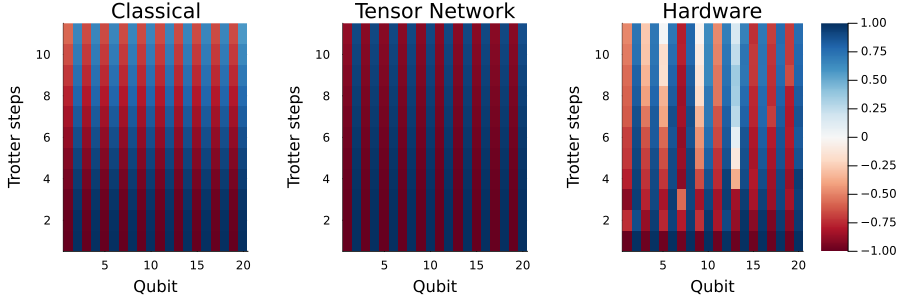

In [29]:
# plot magnetization as a function of time
l = @layout [a{0.3w} b{0.3w} c{0.44w}]
plot(
    heatmap(classical_magnetizations, title="Classical", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=false),
    heatmap(tn_magnetizations, title="Tensor Network", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=false),
    heatmap(magnetizations, title="Hardware", clims=(-1,1), color=:RdBu,
        xlabel="Qubit", ylabel="Trotter steps", colorbar=true),
    layout=l, size=(900,300),
    bottom_margin=5mm, left_margin=5mm, right_margin=6mm
)